# asteroid-colmap: test everything

This notebook checks the package from the unit tests up to the finished Vesta RC3 landmark catalog:

1. **Unit tests**: runs the `pytest` suite.
2. **Building blocks**: the Dawn FC2 camera model, the PDS label parser, the Vesta rotation model
   and the catalog helpers (grading, equal-area cells, pixel frames).
3. **Pipeline** (optional): download the images and run every step again.
4. **Results**: recomputes the catalog's invariants from the CSV files, the camera alignment
   statistics, the duplicate-keypoint checks and the comparison of the two COLMAP modes.
5. **Figures**: redraws every figure and shows the interactive point cloud.

Each check prints `✓` (passed) or `✗` (failed).
The last cell lists them all and raises if any failed.

**Data.** The notebook reads the working directory `$ASTEROID_COLMAP_WORKDIR`, or `work/` in the
repository. If neither holds a catalog, it uses the results committed in `examples/vesta_rc3`.
That folder has only the curated subset, so the checks that need `landmarks.csv` or
`observations.csv` are skipped and the committed figures are shown instead of redrawn.
To rebuild everything from the PDS archive, set `RUN_PIPELINE = True` below. This needs COLMAP
and takes about 5 minutes on a laptop CPU, plus the 540 MB download.

## 1. Setup

In [1]:
import io
import json
import os
import platform
import re
import subprocess
import sys
import tempfile
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

RUN_PIPELINE = False  # True: download the RC3 images and run every step into WORKDIR
MAX_IMAGES = None     # with RUN_PIPELINE: e.g. 30 for a quicker, sparser run

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)


def find_repo(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "pyproject.toml").exists() and (p / "src" / "asteroid_colmap").is_dir():
            return p
    raise FileNotFoundError("start the notebook from inside the asteroid-colmap repository")


REPO = find_repo(Path.cwd().resolve())
WORKDIR = Path(os.environ.get("ASTEROID_COLMAP_WORKDIR", REPO / "work")).resolve()
OTHER = Path(os.environ.get("ASTEROID_COLMAP_OTHER", WORKDIR.with_name(WORKDIR.name + "_inc"))).resolve()
EXAMPLE = REPO / "examples" / "vesta_rc3"


def rel(path) -> str:
    # path for printing: relative to the repository, $WORKDIR or $OTHER, never absolute
    path = Path(path).resolve()
    for root, tag in ((REPO, "."), (WORKDIR, "$WORKDIR"), (OTHER, "$OTHER")):
        if path.is_relative_to(root):
            return f"{tag}/{path.relative_to(root).as_posix()}".removesuffix("/.")
    return path.name


CHECKS = []
SECTION = "setup"


def check(name, ok, detail=""):
    # record one check and print it
    status = "pass" if ok else "FAIL"
    CHECKS.append({"section": SECTION, "check": name, "status": status, "detail": detail})
    print("✓" if ok else "✗", name, f"({detail})" if detail else "")
    return bool(ok)


has_catalog = (WORKDIR / "catalog" / "landmarks.csv").exists()
print("work dir  ", rel(WORKDIR), "(catalog found)" if has_catalog else "(no catalog: examples/vesta_rc3 is used)")
print("second run", rel(OTHER), "(catalog found)" if (OTHER / "catalog" / "landmarks.csv").exists() else "(not found)")

work dir   $WORKDIR (catalog found)
second run $OTHER (catalog found)


In [2]:
from asteroid_colmap.reconstruct import colmap_executable, colmap_version


def pkg_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"


try:
    colmap = colmap_version(colmap_executable())
except FileNotFoundError:
    colmap = "not found (needed only to run the pipeline)"

packages = ["asteroid-colmap", "numpy", "scipy", "pandas", "matplotlib", "astropy", "pillow", "plotly", "pytest"]
display(pd.Series({"python": platform.python_version(), **{p: pkg_version(p) for p in packages}, "COLMAP": colmap},
                  name="version").to_frame())

,version
python,3.14.6
asteroid-colmap,0.1.0
numpy,2.5.3
scipy,1.18.1
pandas,3.0.6
matplotlib,3.11.2
astropy,8.0.1
pillow,12.3.0
plotly,7.1.0
pytest,9.1.1


## 2. Unit tests

The suite in `tests/` covers the label parser, the geometry, the camera model, COLMAP model I/O,
pair selection, the catalog helpers and the reconstruction options. It needs no data and no COLMAP.

In [3]:
SECTION = "unit tests"
res = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider", "tests"],
                     cwd=REPO, capture_output=True, text=True)
lines = res.stdout.strip().splitlines()
if res.returncode:
    print(res.stdout[-5000:], res.stderr[-2000:])
check("pytest suite", res.returncode == 0, lines[-1] if lines else "no output")

✓ pytest suite (40 passed in 0.74s)


True

## 3. Camera model

The Dawn FC2 camera with filter F1 is a pinhole camera with one radial distortion term, taken from
the NAIF instrument kernel and written as COLMAP's `OPENCV` model. The checks:

* `pixel_rays` and `project` must invert each other.
* The field of view must match the nominal value from the focal length and the pixel pitch.
* The distortion must be small: below a pixel at the image corner.
* The focal length is about 10.5 image widths, which is above COLMAP's sanity limit of 10.
  Left alone, COLMAP silently refuses to triangulate from such a camera, so the pipeline raises
  the limit.

In [4]:
SECTION = "camera"
from asteroid_colmap.camera import get_camera
from asteroid_colmap.config import VESTA, get_dataset
from asteroid_colmap.reconstruct import _camera_limits

ds = get_dataset("vesta-rc3")
cam = get_camera(ds.camera)
print(cam)
print(f"COLMAP {cam.colmap_model}: {cam.colmap_params_str()}")
print(f"IFOV {cam.ifov_rad * 1e6:.2f} µrad, i.e. {cam.ifov_rad * 5500:.3f} km/px at 5,500 km")

rng = np.random.default_rng(0)
u, v = rng.uniform(0, cam.width, 10_000), rng.uniform(0, cam.height, 10_000)
rays = cam.pixel_rays(u, v)
uv = cam.project(5500.0 * rays)
err = np.hypot(uv[:, 0] - u, uv[:, 1] - v).max()
check("pixel_rays returns unit vectors", np.allclose(np.linalg.norm(rays, axis=1), 1.0))
check("project(pixel_rays(u, v)) = (u, v)", err < 1e-3, f"max {err:.1e} px over 10,000 random pixels")

edges = cam.pixel_rays(np.array([0.0, cam.width]), np.array([cam.cy, cam.cy]))
fov = np.degrees(np.arccos(edges[0] @ edges[1]))
nominal = 2 * np.degrees(np.arctan(cam.width * cam.pixel_pitch_mm[0] / 2 / cam.focal_length_mm))
check("horizontal field of view", abs(fov / nominal - 1) < 2e-3, f"{fov:.3f}° (nominal {nominal:.3f}°)")

corner = cam.pixel_rays(np.array([0.0]), np.array([0.0]))[0]
pinhole = np.array([cam.fx * corner[0] / corner[2] + cam.cx, cam.fy * corner[1] / corner[2] + cam.cy])
r_dist, r_pin = np.hypot(cam.cx, cam.cy), np.hypot(*(pinhole - [cam.cx, cam.cy]))
check("radial distortion is sub-pixel", abs(r_dist - r_pin) < 1.0,
      f"{r_dist - r_pin:+.2f} px = {100 * (r_dist / r_pin - 1):.3f} % at the corner")

ratio = max(cam.fx, cam.fy) / max(cam.width, cam.height)
limit = _camera_limits(cam)["Mapper.max_focal_length_ratio"]
check("focal length / width exceeds COLMAP's default limit of 10", ratio > 10, f"{ratio:.2f}")
check("the pipeline raises the limit above it", limit > ratio, f"Mapper.max_focal_length_ratio = {limit:.1f}")

FramingCamera(name='Dawn FC2, filter 1 (clear)', focal_length_mm=150.07, pixel_pitch_mm=(0.014004, 0.013995), center_px=(511.5, 511.5), radial_e1_per_mm2=8.4e-06, width=1024, height=1024)
COLMAP OPENCV: 10716.22394,10723.1154,512,512,0.1891764412,0,0,0
IFOV 93.32 µrad, i.e. 0.513 km/px at 5,500 km
✓ pixel_rays returns unit vectors 
✓ project(pixel_rays(u, v)) = (u, v) (max 3.0e-09 px over 10,000 random pixels)
✓ horizontal field of view (5.468° (nominal 5.471°))
✓ radial distortion is sub-pixel (+0.62 px = 0.086 % at the corner)
✓ focal length / width exceeds COLMAP's default limit of 10 (10.47)
✓ the pipeline raises the limit above it (Mapper.max_focal_length_ratio = 20.9)


True

## 4. PDS labels

The first label in `$WORKDIR/raw` is used if the images were downloaded. Otherwise the notebook
uses the trimmed copy of the first RC3 label that the unit tests use. The label record also
checks the rotation model: the sub-spacecraft point computed from the label's J2000 position
must land on the label's own sub-spacecraft latitude and longitude.

In [5]:
SECTION = "labels"
from asteroid_colmap import metadata, pds

raw_labels = sorted((WORKDIR / "raw").glob("*/*.LBL"))
if raw_labels:
    lbl_path, source = raw_labels[0], rel(raw_labels[0])
else:
    sys.path.insert(0, str(REPO / "tests"))
    from conftest import LABEL_TEXT

    lbl_path = Path(tempfile.mkdtemp()) / "2011205_RC3" / "FC21B0003112_11205060002F1C.LBL"
    lbl_path.parent.mkdir()
    lbl_path.write_text(LABEL_TEXT, encoding="latin-1")
    source = "tests/conftest.py (trimmed copy of the first RC3 label)"

lab = pds.read_label(lbl_path)
utc = metadata.parse_time(lab)
print(f"{source}: {len(lab)} keywords, START_TIME = {utc.isoformat()} UTC")
keys = ["INSTRUMENT_ID", "OBSERVATION_ID", "FILTER_NUMBER", "EXPOSURE_DURATION", "QUATERNION",
        "SC_TARGET_POSITION_VECTOR", "SUB_SPACECRAFT_LATITUDE", "SUB_SPACECRAFT_LONGITUDE", "PHASE_ANGLE"]
display(pd.Series({k: lab.get(k) for k in keys}, name="value").to_frame())

q = np.asarray(lab["QUATERNION"], float)
check("QUATERNION is a unit 4-vector", q.shape == (4,) and abs(np.linalg.norm(q) - 1) < 1e-6)
check("START_TIME is in RC3 (2011, day 205)", (utc.year, utc.timetuple().tm_yday) == (2011, 205))

rec = metadata.label_record(lbl_path, VESTA)
check("rotation model reproduces the label's sub-spacecraft point", rec["rotation_model_check_deg"] < 1e-3,
      f"{rec['rotation_model_check_deg'] * 3600:.2f} arcsec")

$WORKDIR/raw/2011205_RC3/FC21B0003112_11205060002F1C.LBL: 168 keywords, START_TIME = 2011-07-24T06:00:02.137000 UTC


,value
INSTRUMENT_ID,FC2
OBSERVATION_ID,FC2_VSA_RC3
FILTER_NUMBER,1
EXPOSURE_DURATION,8.0
QUATERNION,"(0.1744357085, -0.3431161973, -0.9079719753, 0.1656211065)"
SC_TARGET_POSITION_VECTOR,"(1102.517, -2285.015, -4857.051)"
SUB_SPACECRAFT_LATITUDE,15.197632
SUB_SPACECRAFT_LONGITUDE,-58.343917
PHASE_ANGLE,42.713278


✓ QUATERNION is a unit 4-vector 
✓ START_TIME is in RC3 (2011, day 205) 
✓ rotation model reproduces the label's sub-spacecraft point (2.27 arcsec)


True

## 5. Rotation model and quaternions

Vesta's body-fixed frame is Claudia double-prime: the IAU pole and spin rate, with the prime
meridian moved to the Claudia crater convention.

In [6]:
SECTION = "rotation model"
from asteroid_colmap import geometry as geo

R = geo.body_from_j2000(VESTA, utc)
check("body_from_j2000 is a proper rotation", np.allclose(R @ R.T, np.eye(3), atol=1e-12) and np.isclose(np.linalg.det(R), 1.0))
pole = geo.latlon_to_unit(VESTA.pole_dec_deg, VESTA.pole_ra_deg)
check("body +z axis is the IAU pole", np.allclose(R.T @ [0.0, 0.0, 1.0], pole, atol=1e-12),
      f"RA {VESTA.pole_ra_deg}°, Dec {VESTA.pole_dec_deg}°")
period_h = 360.0 / VESTA.w_rate_deg_per_day * 24
check("sidereal rotation period", abs(period_h - 5.342) < 1e-3, f"{period_h:.4f} h")

worst = 0.0
for qi in rng.normal(size=(1000, 4)):
    qi /= np.linalg.norm(qi)
    q2 = geo.matrix_to_quat(geo.quat_to_matrix(qi))
    worst = max(worst, min(np.abs(qi - q2).max(), np.abs(qi + q2).max()))
check("quaternion → matrix → quaternion (up to sign)", worst < 1e-12, f"max error {worst:.1e} over 1,000 random rotations")

✓ body_from_j2000 is a proper rotation 
✓ body +z axis is the IAU pole (RA 309.031°, Dec 42.235°)
✓ sidereal rotation period (5.3421 h)
✓ quaternion → matrix → quaternion (up to sign) (max error 5.6e-16 over 1,000 random rotations)


True

## 6. Catalog helpers

* **Grades.** A landmark gets grade A or B when it meets all three thresholds in `GRADES`
  (track length, triangulation angle, reprojection error), and C otherwise.
* **Equal-area cells.** The curated subset keeps one landmark per cell of about 10 km × 10 km.
  For 400,000 random points on a sphere, the cell count must match the area ratio, and the
  scatter of the points per cell must be pure Poisson noise. Any extra scatter would mean
  unequal cells.
* **Pixel frames.** The FITS arrays are stored bottom-up, so the prepared PNGs are flipped
  up-down (`ud`). `pixel_frames` maps COLMAP pixels back to the stored FITS rows.

In [7]:
SECTION = "catalog helpers"
from asteroid_colmap.catalog import GRADES, equal_area_cells, grade, pixel_frames

(nA, angA, errA), (nB, angB, errB) = GRADES["A"], GRADES["B"]
cases = pd.DataFrame(
    [("exactly at the A thresholds", nA, angA, errA, "A"),
     ("A, but one image short", nA - 1, angA, errA, "B"),
     ("A, but error 0.01 px too high", nA, angA, errA + 0.01, "B"),
     ("exactly at the B thresholds", nB, angB, errB, "B"),
     ("B, but angle 0.01° too small", nB, angB - 0.01, errB, "C"),
     ("wide angle, small error, only 3 images", 3, 60.0, 0.1, "C")],
    columns=["case", "track", "tri_angle_deg", "error_px", "expected"])
cases["grade"] = grade(cases.track.to_numpy(), cases.tri_angle_deg.to_numpy(), cases.error_px.to_numpy())
display(cases)
check("grade() at the threshold edges", (cases.grade == cases.expected).all())

R_MEAN = float(np.mean(VESTA.radii_km))
p = rng.normal(size=(400_000, 3))
lat, lon, _ = geo.cart_to_latlonr(p / np.linalg.norm(p, axis=1, keepdims=True))
counts = pd.Series(equal_area_cells(lat, lon, 10.0, R_MEAN)).value_counts()
n_cells = 4 * np.pi * R_MEAN**2 / 10.0**2
check("10 km cells tile the sphere", abs(len(counts) / n_cells - 1) < 0.01, f"{len(counts):,} cells, 4πR²/s² = {n_cells:,.0f}")
scatter = counts.std() / np.sqrt(counts.mean())
check("cells have equal area", scatter < 1.1, f"std / √mean of points per cell = {scatter:.2f}; 1 for Poisson noise")

f = pixel_frames(np.array([0.5, cam.width - 0.5]), np.array([0.5, cam.height - 0.5]), "ud", cam)
check("'ud' flip: the first PNG row is the last FITS row",
      np.allclose(f["line_ik"], [0, cam.height - 1]) and np.allclose(f["fits_row"], [cam.height - 1, 0])
      and np.allclose(f["fits_col"], f["sample_ik"]))

,case,track,tri_angle_deg,error_px,expected,grade
0,exactly at the A thresholds,8,15.00,1.00,A,A
1,"A, but one image short",7,15.00,1.00,B,B
2,"A, but error 0.01 px too high",8,15.00,1.01,B,B
3,exactly at the B thresholds,4,5.00,2.00,B,B
4,"B, but angle 0.01° too small",4,4.99,2.00,C,C
5,"wide angle, small error, only 3 images",3,60.00,0.10,C,C


✓ grade() at the threshold edges 
✓ 10 km cells tile the sphere (8,674 cells, 4πR²/s² = 8,672)
✓ cells have equal area (std / √mean of points per cell = 1.00; 1 for Poisson noise)
✓ 'ud' flip: the first PNG row is the last FITS row 


True

## 7. Pipeline (optional)

With `RUN_PIPELINE = True`, this cell runs `asteroid-colmap run -w WORKDIR`. That downloads the
RC3 images and labels (about 540 MB), then prepares the images, runs COLMAP, builds the catalog
and draws the figures. Otherwise the existing results are used.

In [8]:
SECTION = "pipeline"
if RUN_PIPELINE:
    from asteroid_colmap import cli

    argv = ["run", "-w", str(WORKDIR)] + (["--max-images", str(MAX_IMAGES)] if MAX_IMAGES else [])
    status = cli.main(argv)
    check("asteroid-colmap run", status == 0, f"exit status {status}")
else:
    print("RUN_PIPELINE is False: using the existing results")

RUN_PIPELINE is False: using the existing results


## 8. Catalog invariants

These checks recompute what each column of the catalog promises from the other columns:

* coordinates against `x/y/z`;
* height against the ellipsoid;
* grades against `GRADES`;
* the outlier flag;
* the ground sample distance;
* the ID order;
* the curated subset, checked against its scoring rule:
  track length × min(triangulation angle, 30°) / max(error, 0.2 px), best per cell.

With only the committed examples, the checks run on the curated subset.

In [9]:
SECTION = "catalog"
CAT = WORKDIR / "catalog"
FULL = (CAT / "landmarks.csv").exists()
SRC = CAT if FULL else EXAMPLE
curated = pd.read_csv(SRC / "landmarks_curated.csv")
cams = pd.read_csv(SRC / "cameras.csv")
summary = json.loads((SRC / "summary.json").read_text())
lm = pd.read_csv(CAT / "landmarks.csv") if FULL else curated
obs = pd.read_csv(CAT / "observations.csv") if FULL else None
print(f"reading {rel(SRC)}:", "full catalog" if FULL else "curated subset only (landmarks.csv and observations.csv are not committed)")

al = summary["alignment"]
grades = " / ".join(f"{summary['grades'].get(g, 0):,}" for g in "ABC")
display(pd.Series({
    "registered images": f"{summary['num_registered_images']} of {summary['num_input_images']}",
    "landmarks (A / B / C)": f"{summary['num_landmarks']:,} ({grades})",
    "curated landmarks": f"{summary['num_curated_landmarks']:,} (one per {summary.get('curated_spacing_km') or 10:g} km cell)",
    "observations": f"{summary['num_observations']:,}",
    "median track length": f"{summary['median_track_length']:.0f} images",
    "median reprojection error": f"{summary['median_reproj_error_px']:.3f} px",
    "median triangulation angle": f"{summary['median_tri_angle_deg']:.1f}°",
    "height p05 / p50 / p95": " / ".join(f"{h:+.2f}" for h in summary["height_km_p05_p50_p95"]) + " km",
    "camera position RMS vs labels": f"{al['position_rms_km']:.2f} km",
    "attitude median vs labels": f"{al['attitude_median_deg']:.4f}°",
}, name="RC3").to_frame())

reading $WORKDIR/catalog: full catalog


,RC3
registered images,130 of 130
landmarks (A / B / C),"94,576 (33,962 / 41,026 / 19,588)"
curated landmarks,"7,487 (one per 10 km cell)"
observations,"824,085"
median track length,6 images
median reprojection error,0.238 px
median triangulation angle,34.5°
height p05 / p50 / p95,-9.74 / -0.87 / +8.31 km
camera position RMS vs labels,2.15 km
attitude median vs labels,0.0225°


In [10]:
MAX_HEIGHT_KM = 60.0  # default of `asteroid-colmap catalog --max-height`
xyz = lm[["x_km", "y_km", "z_km"]].to_numpy()
radius = np.linalg.norm(xyz, axis=1)
direction = geo.latlon_to_unit(lm.lat_deg.to_numpy(), lm.lon_deg.to_numpy())
ell = geo.ellipsoid_radius(lm.lat_deg, lm.lon_deg, VESTA.radii_km)

check("landmark IDs are unique LMK_nnnnnn", lm.landmark_id.is_unique and lm.landmark_id.str.fullmatch(r"LMK_\d{6}").all(),
      f"{len(lm):,} landmarks")
check("lat/lon/radius match x/y/z",
      np.abs(direction - xyz / radius[:, None]).max() < 1e-6 and np.abs(radius - lm.radius_km).max() < 1e-5)
check("ellipsoid_radius_km and height_km", np.abs(ell - lm.ellipsoid_radius_km).max() < 1e-5
      and np.abs(lm.radius_km - ell - lm.height_km).max() < 1e-5)
regrade = grade(lm.track_length.to_numpy(), lm.max_tri_angle_deg.to_numpy(), lm.reproj_error_px.to_numpy())
n_bad = int((regrade != lm.grade.to_numpy()).sum())
check("grades follow GRADES", n_bad <= 1e-4 * len(lm), f"{n_bad} mismatches; 0.01 % allowed for CSV rounding")
check("outlier = |height| > 60 km", (lm.outlier == (lm.height_km.abs() > MAX_HEIGHT_KM)).all(), f"{int(lm.outlier.sum())} outliers")
check("gsd_km = mean range × IFOV", np.allclose(lm.gsd_km, lm.mean_range_km * cam.ifov_rad, rtol=1e-5, atol=2e-6),
      f"median {lm.gsd_km.median():.3f} km/px")
check("IDs follow quality order (outliers last, then grade)",
      lm.landmark_id.is_monotonic_increasing and lm.outlier.is_monotonic_increasing
      and lm[~lm.outlier].grade.is_monotonic_increasing)

spacing = summary.get("curated_spacing_km") or 10.0
cells = equal_area_cells(curated.lat_deg, curated.lon_deg, spacing, R_MEAN)
check("curated: grades A/B only, no outliers", curated.grade.isin(["A", "B"]).all() and not curated.outlier.any())
check("curated: at most one landmark per cell", pd.Series(cells).is_unique, f"{len(curated):,} landmarks, {spacing:g} km cells")
check("summary.json: curated count", summary["num_curated_landmarks"] == len(curated))

if FULL:
    check("curated ⊂ landmarks", curated.landmark_id.isin(lm.landmark_id).all())
    good = lm[~lm.outlier & lm.grade.isin(["A", "B"])].copy()
    good["cell"] = equal_area_cells(good.lat_deg, good.lon_deg, spacing, R_MEAN)
    good["score"] = good.track_length * np.minimum(good.max_tri_angle_deg, 30.0) / np.maximum(good.reproj_error_px, 0.2)
    best = good.groupby("cell").score.max()
    picked = good[good.landmark_id.isin(curated.landmark_id)]
    ties = int(good.groupby("cell").score.apply(lambda s: (s == s.max()).sum() > 1).sum())
    check("curated covers every cell with an A/B candidate", set(picked.cell) == set(best.index),
          f"{len(best):,} cells")
    check("each curated landmark has its cell's best score",
          np.allclose(picked.score, best.reindex(picked.cell), rtol=1e-6),
          f"{ties} cells have a tie for best; either landmark is valid")
    check("summary.json: landmark, grade, outlier and observation counts",
          summary["num_landmarks"] == len(lm) and summary["grades"] == lm.grade.value_counts().to_dict()
          and summary["num_outliers"] == int(lm.outlier.sum()) and summary["num_observations"] == len(obs))

✓ landmark IDs are unique LMK_nnnnnn (94,576 landmarks)
✓ lat/lon/radius match x/y/z 
✓ ellipsoid_radius_km and height_km 
✓ grades follow GRADES (0 mismatches; 0.01 % allowed for CSV rounding)
✓ outlier = |height| > 60 km (3 outliers)
✓ gsd_km = mean range × IFOV (median 0.493 km/px)
✓ IDs follow quality order (outliers last, then grade) 
✓ curated: grades A/B only, no outliers 
✓ curated: at most one landmark per cell (7,487 landmarks, 10 km cells)
✓ summary.json: curated count 
✓ curated ⊂ landmarks 


✓ curated covers every cell with an A/B candidate (7,487 cells)


✓ each curated landmark has its cell's best score (176 cells have a tie for best; either landmark is valid)
✓ summary.json: landmark, grade, outlier and observation counts 


### Observations

`observations.csv` has one row per landmark measurement in one image (full catalog only). The
checks tie it back to the track lengths, to the per-image counts and reprojection RMS in
`cameras.csv`, and to the image flip.

In [11]:
if FULL:
    reg = cams[cams.registered]
    per_lm = obs.groupby("landmark_id").size()
    check("track_length = observations per landmark", per_lm.reindex(lm.landmark_id).eq(lm.track_length.to_numpy()).all(),
          f"{len(obs):,} observations")
    per_img = obs.groupby("image").size()
    check("num_landmarks = observations per image", np.array_equal(per_img.reindex(reg.image).to_numpy(), reg.num_landmarks.to_numpy()))
    rms = np.sqrt((obs.residual_u_px**2 + obs.residual_v_px**2).groupby(obs.image).mean())
    check("reproj_rms_px = RMS of the image's residuals", np.allclose(rms.reindex(reg.image), reg.reproj_rms_px, atol=1e-3),
          f"median {reg.reproj_rms_px.median():.3f} px")
    flip = summary["image_flip"]
    frames = pixel_frames(obs.u.to_numpy(), obs.v.to_numpy(), flip, cam)
    worst = max(np.abs(frames[c] - obs[c].to_numpy()).max() for c in frames)
    check(f"IK and FITS pixel columns follow the '{flip}' flip", worst < 1e-3, f"max {worst:.1e} px")
else:
    print("observations.csv not available: skipped")

✓ track_length = observations per landmark (824,085 observations)
✓ num_landmarks = observations per image 
✓ reproj_rms_px = RMS of the image's residuals (median 0.669 px)
✓ IK and FITS pixel columns follow the 'ud' flip (max 1.1e-13 px)


## 9. Cameras and alignment

The model is aligned to the label poses with a similarity transform. These checks recompute the
summary statistics from the per-image rows of `cameras.csv`. They also cross-check two label
quantities against the rotation model and the camera:

* The sub-spacecraft point must agree with the rotation model.
* The label's pixel scale must equal (range − surface radius) × IFOV.

In [12]:
SECTION = "cameras"
reg = cams[cams.registered]
used = reg[reg.used_in_fit.astype(bool)]
check("cameras.csv lists every input image", len(cams) == summary["num_input_images"], f"{len(cams)} images")
check("at least 90 % of images registered", len(reg) == summary["num_registered_images"] and len(reg) >= 0.9 * len(cams),
      f"{len(reg)} of {len(cams)}")
check("rotation model vs every label's sub-spacecraft point", cams.rotation_model_check_deg.max() < 1e-3,
      f"max {cams.rotation_model_check_deg.max() * 3600:.2f} arcsec")
surface = geo.ellipsoid_radius(cams.subsc_lat_deg, cams.subsc_lon_deg, VESTA.radii_km)
scale_err = ((cams.range_km - surface) * cam.ifov_rad / cams.pixel_scale_km - 1).abs().max()
check("label pixel scale = (range − surface radius) × IFOV", scale_err < 5e-3,
      f"max {100 * scale_err:.2f} %; the label gives 3 decimals")

rms = float(np.sqrt((used.position_residual_km**2).mean()))
check("position RMS recomputed = summary", abs(rms - al["position_rms_km"]) < 1e-3, f"{rms:.3f} km")
check("camera positions agree with the labels (RMS < 5 km)", rms < 5.0,
      f"{rms:.2f} km = {100 * rms / reg.range_km.median():.3f} % of the range")
att = float(reg.attitude_residual_deg.median())
check("attitude median recomputed = summary", abs(att - al["attitude_median_deg"]) < 1e-5, f"{att:.4f}°")
check("attitudes agree with the labels (median < 0.05°)", att < 0.05, f"{np.radians(att) / cam.ifov_rad:.1f} px")
bore = float(np.hypot(reg.boresight_du_px, reg.boresight_dv_px).median())
check("boresight median recomputed = summary", abs(bore - al["boresight_median_px"]) < 1e-3, f"{bore:.2f} px")
check("model is neither mirrored nor reversed", not al["mirrored_or_reversed"])

✓ cameras.csv lists every input image (130 images)
✓ at least 90 % of images registered (130 of 130)
✓ rotation model vs every label's sub-spacecraft point (max 2.43 arcsec)
✓ label pixel scale = (range − surface radius) × IFOV (max 0.29 %; the label gives 3 decimals)
✓ position RMS recomputed = summary (2.150 km)
✓ camera positions agree with the labels (RMS < 5 km) (2.15 km = 0.039 % of the range)
✓ attitude median recomputed = summary (0.0225°)
✓ attitudes agree with the labels (median < 0.05°) (4.2 px)
✓ boresight median recomputed = summary (3.75 px)
✓ model is neither mirrored nor reversed 


True

## 10. Duplicate keypoints

SIFT gives a keypoint with two dominant gradient directions a second orientation, and stores it
as a second keypoint at the same pixel. The two copies can be matched into different tracks,
which turns one surface feature into two landmarks a few hundred metres apart. COLMAP's
covariant extractor, used for DSP-SIFT, ignores `SiftExtraction.max_num_orientations`, so the
package removes the copies from the database after extraction
(`reconstruct.drop_duplicate_keypoints`). COLMAP can also put two distinct keypoints of one
image, a few pixels apart, in the same track; the catalog keeps the one closer to the projection
(`catalog.one_observation_per_image`).

This cell checks that:

* no image in the feature database has two keypoints at the same pixel;
* no two landmarks share a keypoint (same image, same pixel);
* no landmark is observed twice in one image.

In [13]:
SECTION = "duplicate keypoints"
db = WORKDIR / "colmap" / "database.db"
if db.exists():
    import sqlite3
    from contextlib import closing
    with closing(sqlite3.connect(db.as_uri() + "?mode=ro", uri=True)) as con:
        rows = con.execute("SELECT rows, cols, data FROM keypoints").fetchall()
    n_kp = sum(n for n, _, _ in rows)
    repeats = sum(n - len(np.unique(np.frombuffer(data, np.float32).reshape(n, cols)[:, :2], axis=0))
                  for n, cols, data in rows if n)
    check("database: one keypoint per pixel", repeats == 0,
          f"{repeats:,} repeats among {n_kp:,} keypoints in {len(rows)} images")
else:
    print(rel(db), "not found: database check skipped")
if FULL:
    kp = obs[["landmark_id", "image", "u", "v"]]
    same_image = int(kp.duplicated(["landmark_id", "image"]).sum())
    shared = kp[kp.duplicated(["image", "u", "v"], keep=False)]
    pairs = (shared.merge(shared, on=["image", "u", "v"]).query("landmark_id_x < landmark_id_y")
             .drop_duplicates(["landmark_id_x", "landmark_id_y"]))
    check("no two landmarks share a keypoint", len(pairs) == 0,
          f"{len(shared):,} of {len(kp):,} observations share a pixel; {len(pairs):,} landmark pairs")
    check("no landmark is observed twice in one image", same_image == 0, f"{same_image:,} repeated observations")
else:
    print("observations.csv not available: skipped")

✓ database: one keypoint per pixel (0 repeats among 996,733 keypoints in 130 images)
✓ no two landmarks share a keypoint (0 of 824,085 observations share a pixel; 0 landmark pairs)
✓ no landmark is observed twice in one image (0 repeated observations)


## 11. Label-poses mode vs incremental mode

The default `label-poses` mode triangulates with the camera poses fixed to the labels. The
`incremental` mode lets COLMAP solve everything from scratch. `compare_catalogs` pairs the
landmarks of two runs by the keypoints they share, then measures the 3-D differences. Once the
small mean offset between the two models is removed, the matched landmarks should agree to a
small fraction of a pixel footprint.

In [14]:
SECTION = "mode comparison"
from asteroid_colmap.catalog import compare_catalogs

cmp_path = next(p for p in (WORKDIR / "compare_incremental.json", EXAMPLE / "compare_incremental.json") if p.exists())
cmp = json.loads(cmp_path.read_text())
n_a, n_b = cmp["num_landmarks"]
frac = cmp["num_matched"] / min(n_a, n_b)
p50, p90 = cmp["distance_minus_offset_km_p50_p90"]
offset = float(np.linalg.norm(cmp["mean_offset_km"]))
gsd = float(cams.pixel_scale_km.median())
print(f"reading {rel(cmp_path)}")
display(pd.Series({
    "landmarks (label-poses / incremental)": f"{n_a:,} / {n_b:,}",
    "matched": f"{cmp['num_matched']:,} ({100 * frac:.1f} % of the smaller catalog)",
    "3-D distance p50 / p90 / p99": " / ".join(f"{1000 * d:.0f}" for d in cmp["distance_km_p50_p90_p99"]) + " m",
    "mean offset": f"{1000 * offset:.0f} m",
    "distance after removing the offset, p50 / p90": f"{1000 * p50:.0f} / {1000 * p90:.0f} m",
    "pixel footprint (median label pixel scale)": f"{1000 * gsd:.0f} m",
}, name="comparison").to_frame())

check("most landmarks are found in both modes", frac > 0.85, f"{100 * frac:.1f} %")
check("matched landmarks agree after removing the offset", p50 < 0.1 * gsd, f"p50 {1000 * p50:.0f} m < 10 % of a pixel footprint")
check("mean offset is below one pixel footprint", offset < gsd, f"{1000 * offset:.0f} m")
if FULL and (OTHER / "catalog" / "observations.csv").exists():
    fresh = compare_catalogs(CAT, OTHER / "catalog")
    same = (fresh["num_matched"] == cmp["num_matched"]
            and np.allclose(fresh["distance_minus_offset_km_p50_p90"], cmp["distance_minus_offset_km_p50_p90"]))
    check("compare_catalogs reproduces the stored comparison", same, f"{fresh['num_matched']:,} matched")
else:
    print("second catalog not found: the stored comparison is not recomputed")

reading ./examples/vesta_rc3/compare_incremental.json


,comparison
landmarks (label-poses / incremental),"94,576 / 94,331"
matched,"92,292 (97.8 % of the smaller catalog)"
3-D distance p50 / p90 / p99,98 / 124 / 1993 m
mean offset,100 m
"distance after removing the offset, p50 / p90",16 / 46 m
pixel footprint (median label pixel scale),486 m


✓ most landmarks are found in both modes (97.8 %)
✓ matched landmarks agree after removing the offset (p50 16 m < 10 % of a pixel footprint)
✓ mean offset is below one pixel footprint (100 m)


✓ compare_catalogs reproduces the stored comparison (92,292 matched)


## 12. Figures

With a full workspace, `make_all` redraws every figure into `$WORKDIR/plots`. The house style
is applied inside each plot call only, so your matplotlib settings must be unchanged afterwards.
Without a workspace, the committed figures from `examples/vesta_rc3/plots` are shown.
The figures are embedded as reduced JPEG copies to keep the notebook small.

✓ make_all leaves matplotlib's rcParams unchanged 
✓ all 11 figures drawn (11 PNGs in $WORKDIR/plots)


**02_geometry**: sub-spacecraft ground track with the polar-night band; range and phase against hours since sequence start

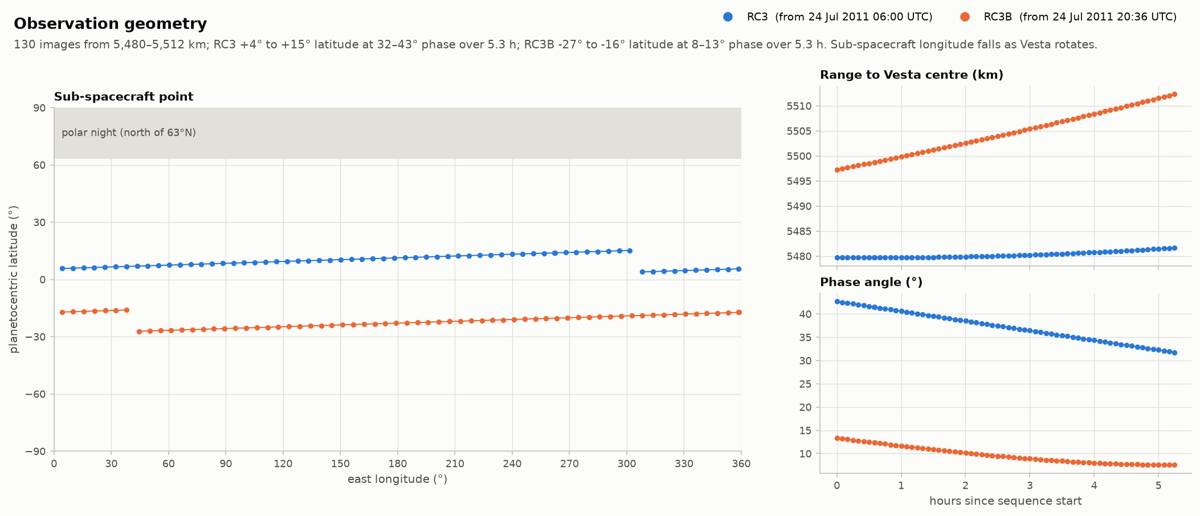

**01_montage**: prepared input frames, evenly spaced in time

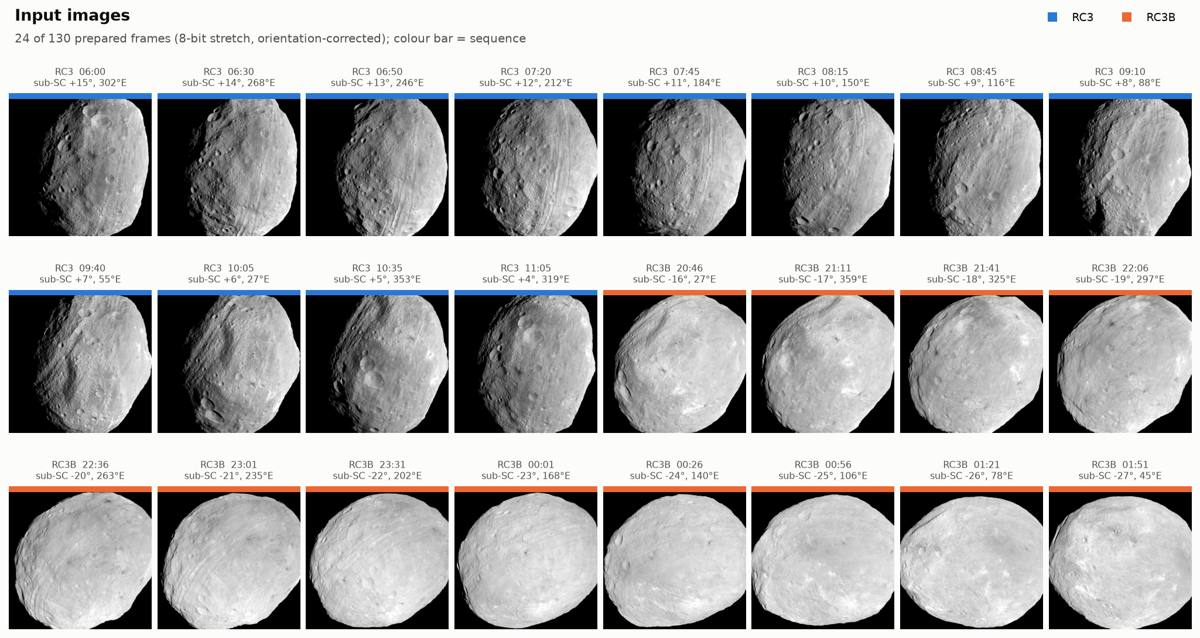

**03_orientation_check**: observed silhouettes against the label-predicted lit ellipsoid, for every flip

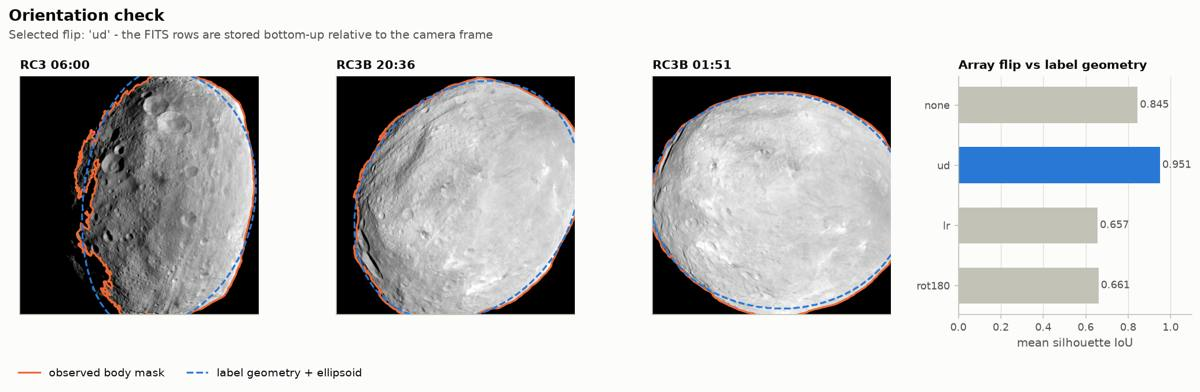

**04_features**: landmark observations on the best-connected image of each sequence

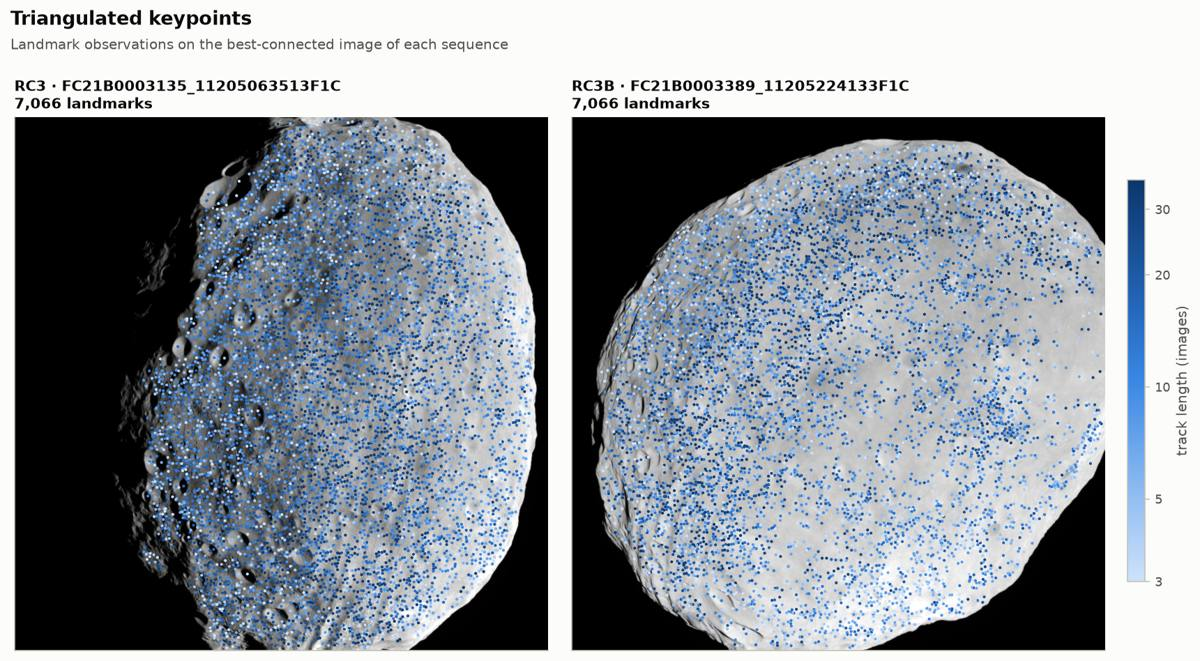

**05_covisibility**: landmarks shared by every image pair

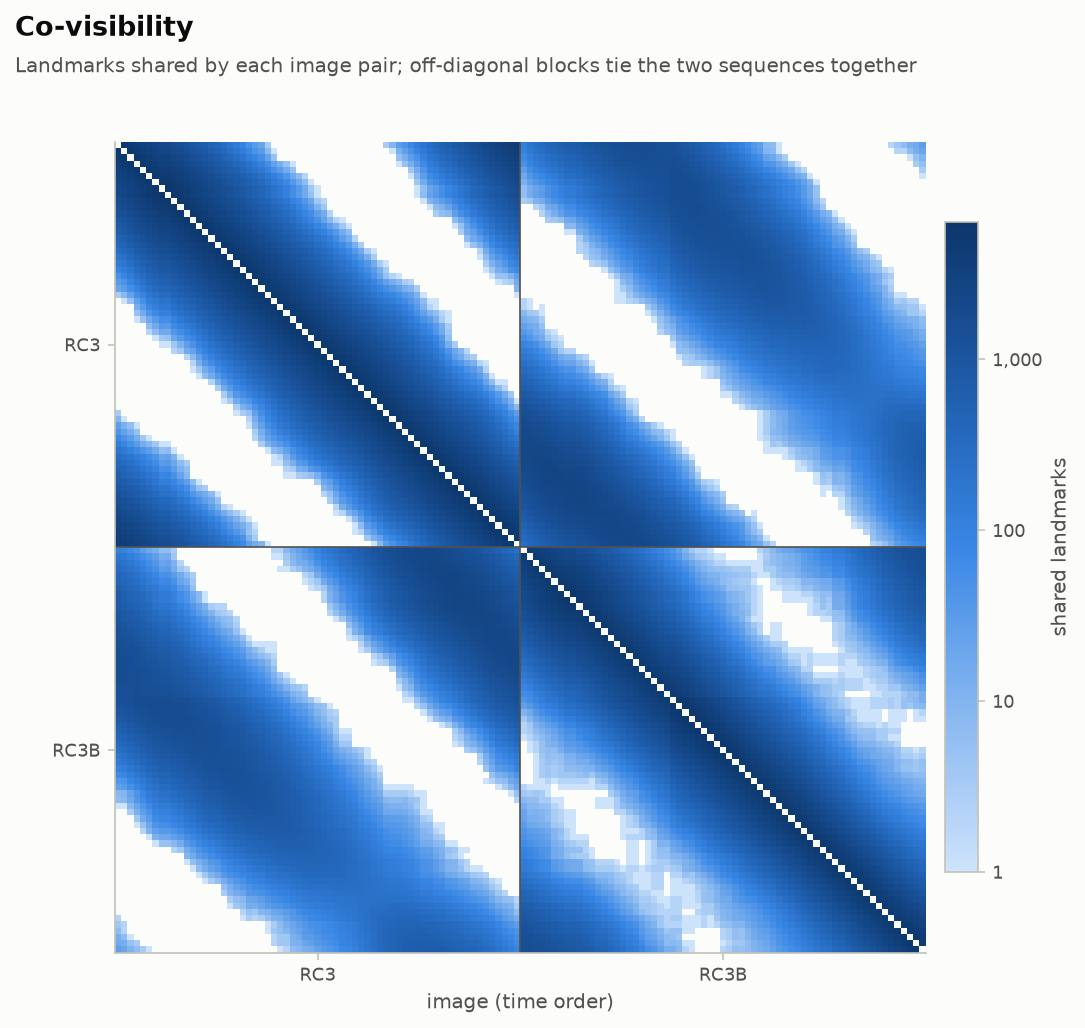

**06_alignment**: per-image position residual, boresight offset and twist relative to the label poses

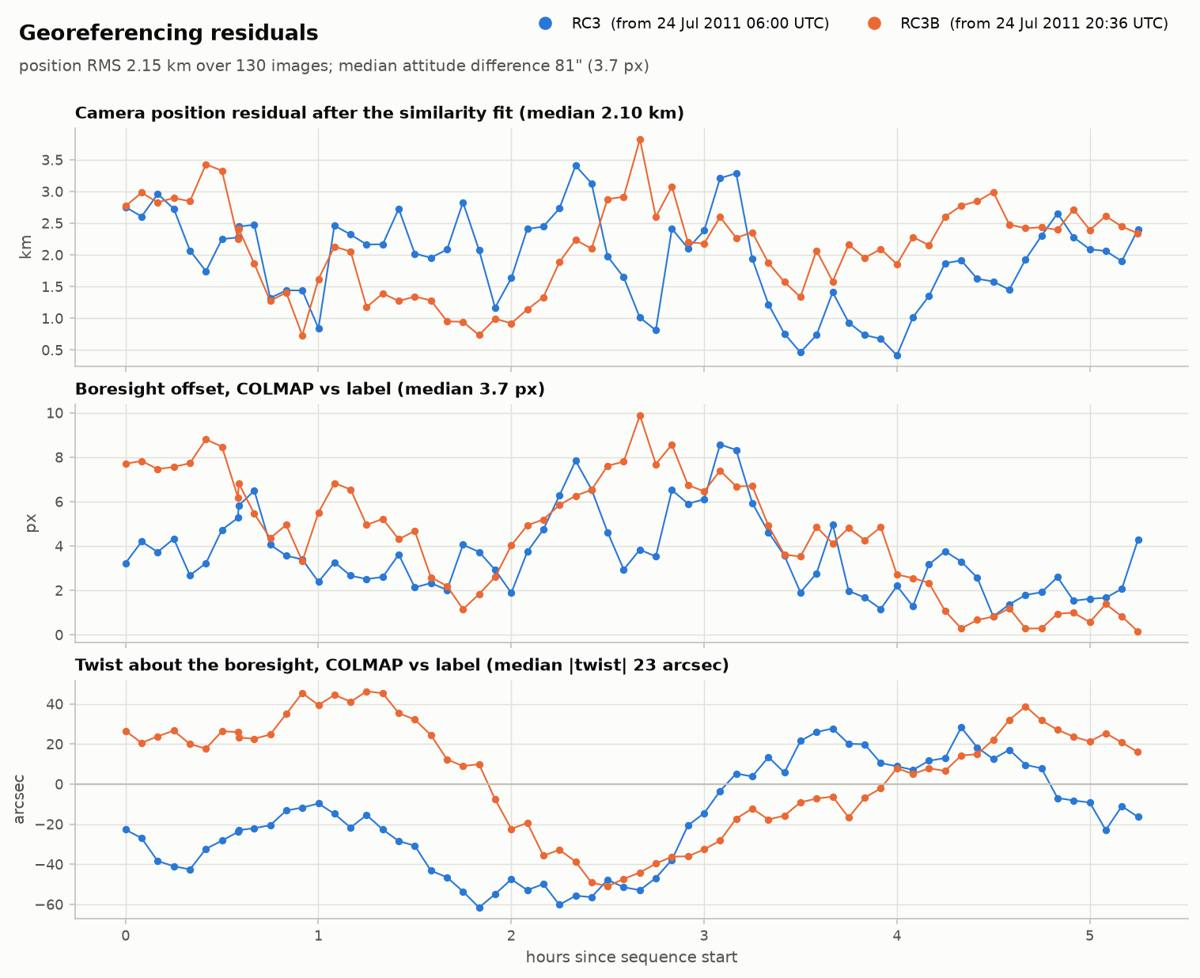

**07_pointcloud**: four orthographic globe views of the landmarks, coloured by height

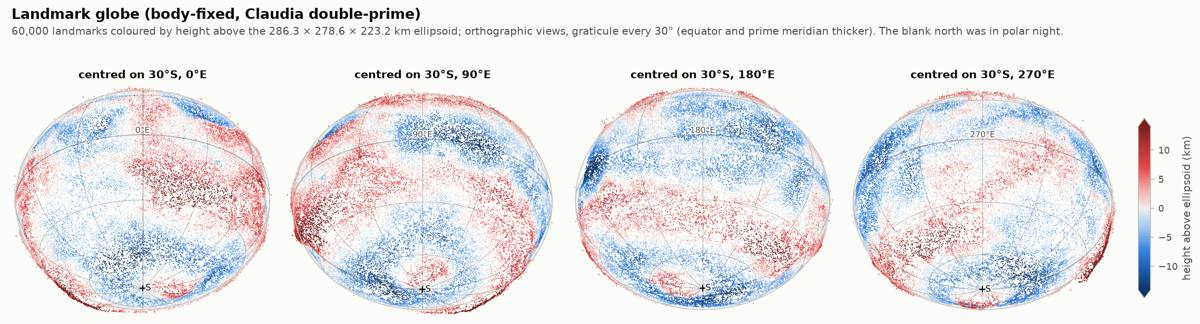

**08_landmark_map**: equirectangular map by height, curated subset by track length, south-polar view of Rheasilvia

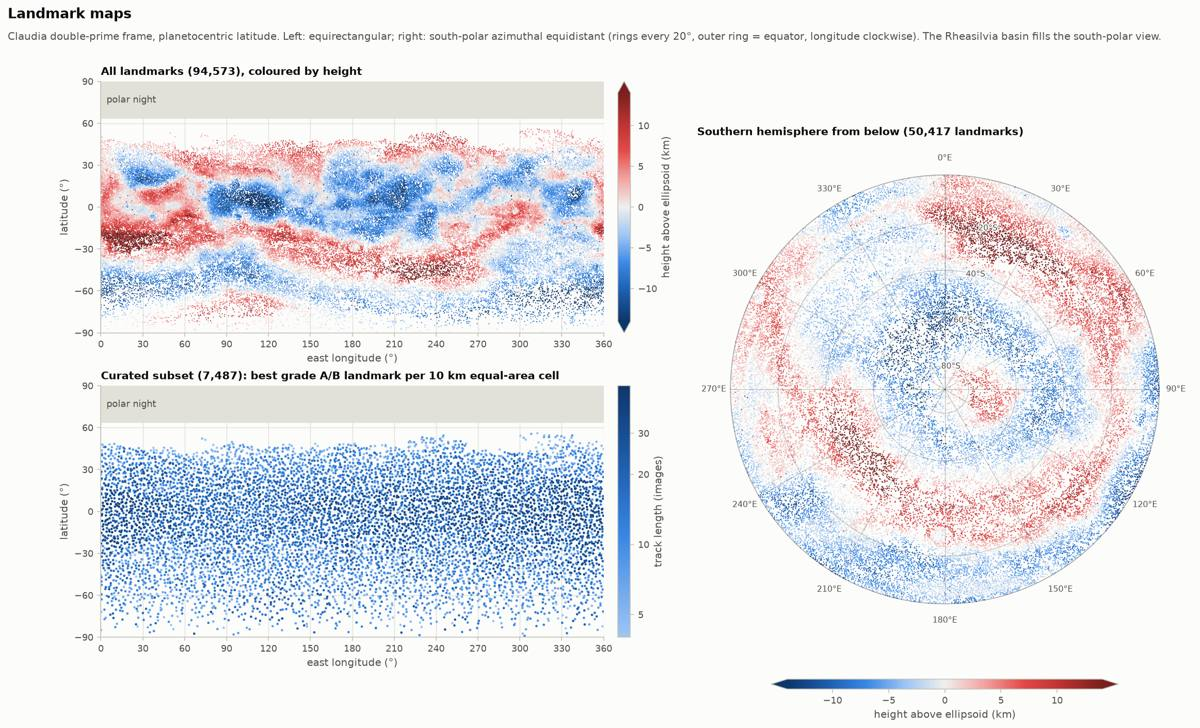

**09_quality**: track length, reprojection error, triangulation angle and height, stacked by grade

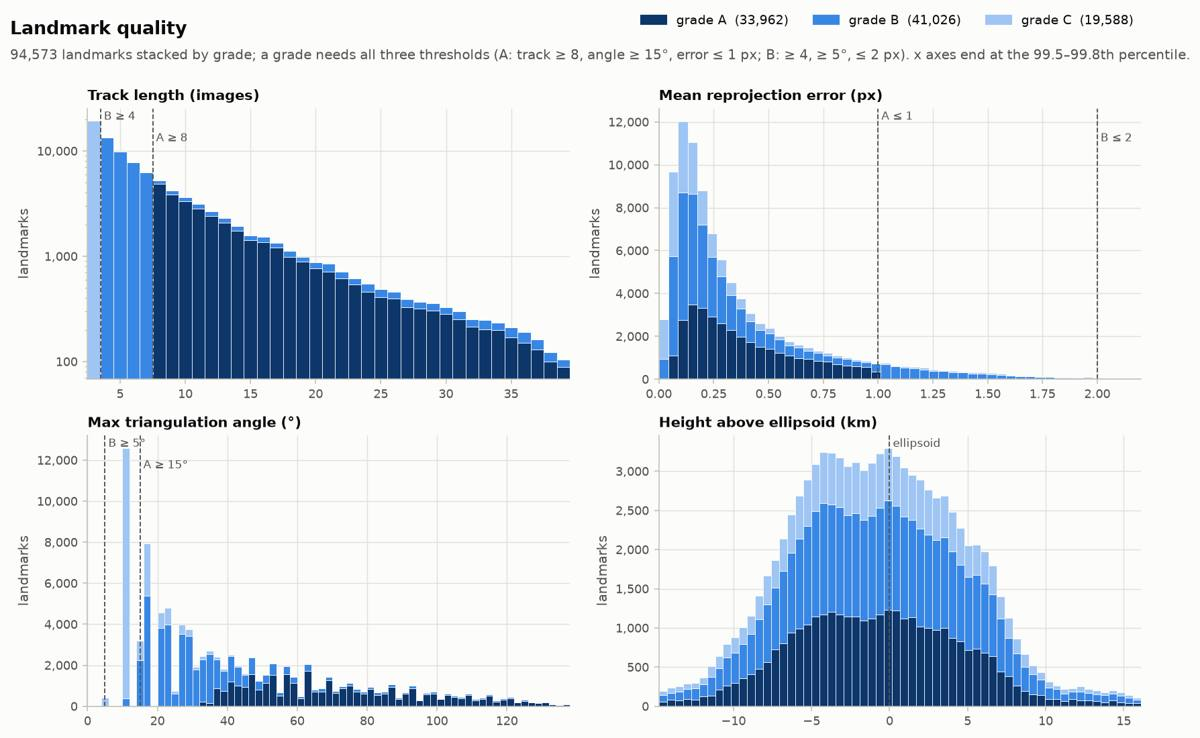

**10_radius_vs_latitude**: height against latitude as a log-density hexbin, with the median and quartiles per 5° band

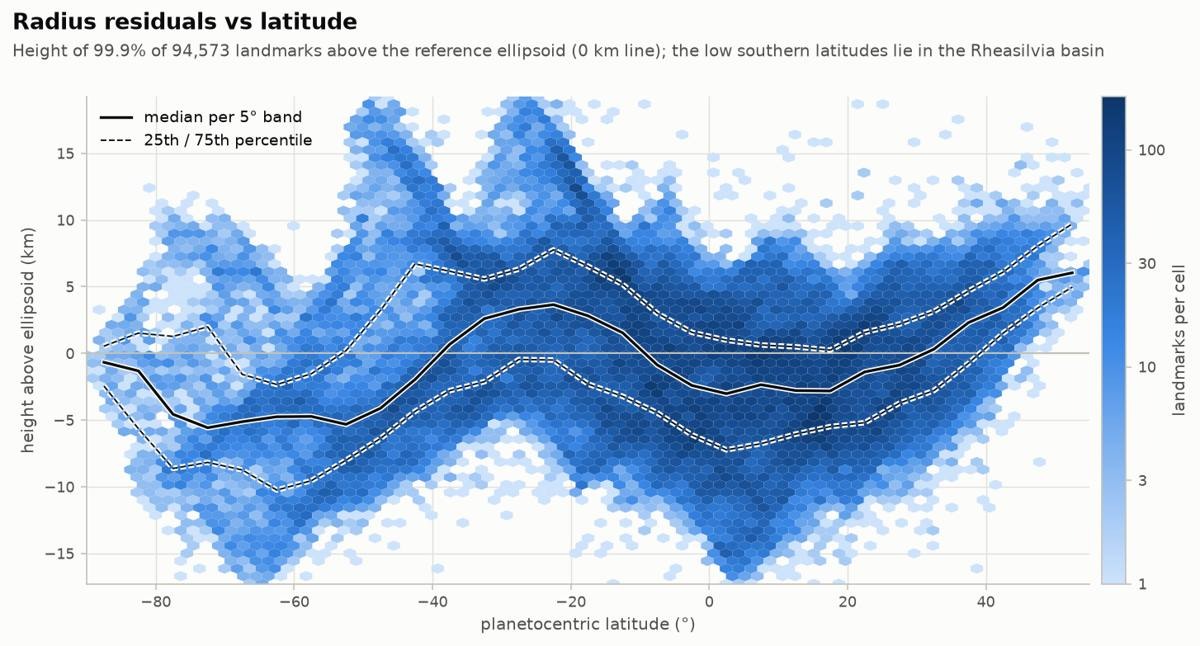

**11_landmark_chips**: image patches of grade A landmarks across their views

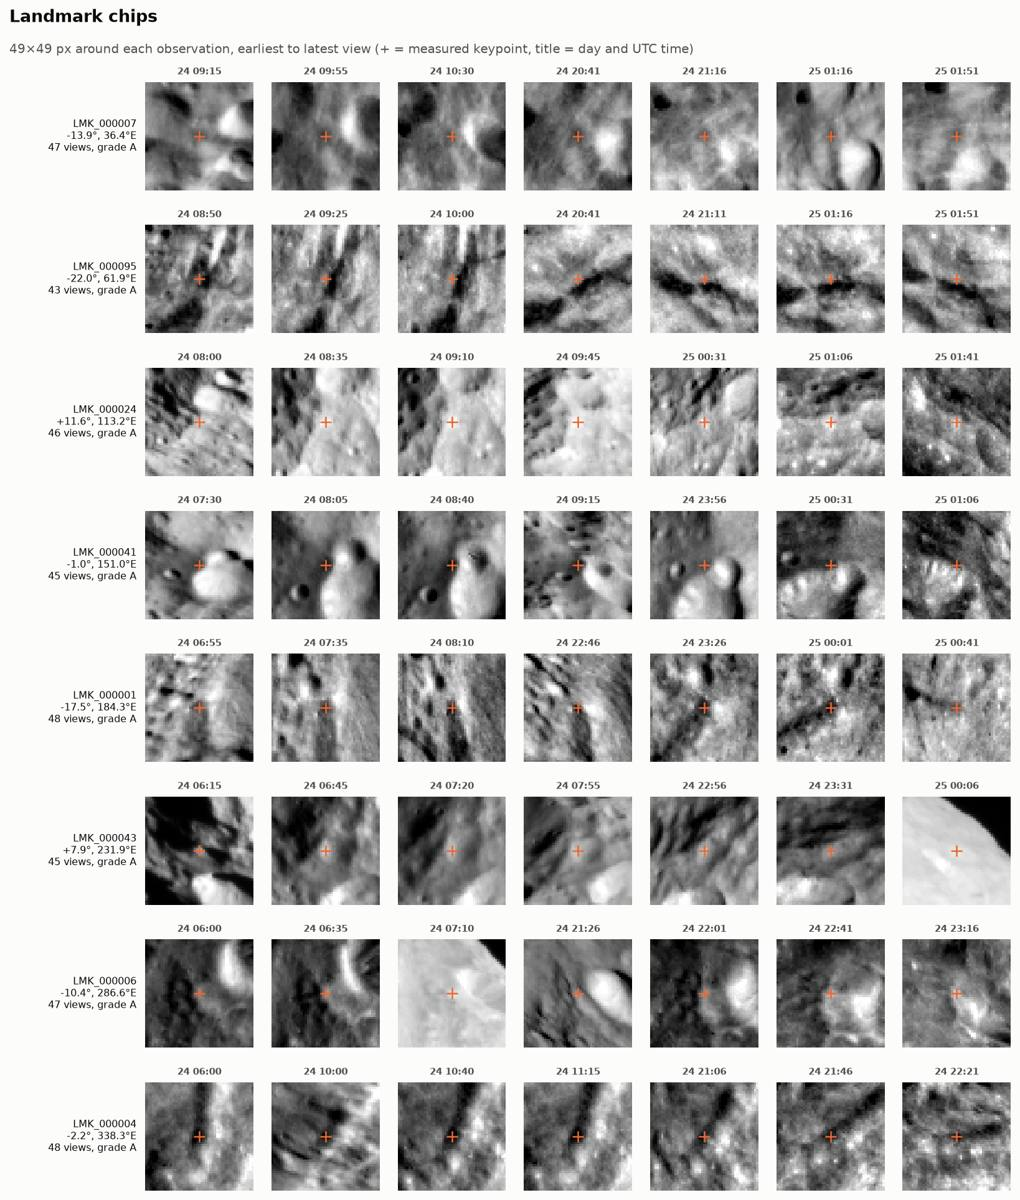

In [15]:
SECTION = "figures"
import matplotlib as mpl
from PIL import Image as PILImage

from asteroid_colmap import plots
from asteroid_colmap.workspace import Workspace

if FULL and (WORKDIR / "metadata.csv").exists():
    before = dict(mpl.rcParams)
    written = plots.make_all(Workspace(WORKDIR), ds, interactive=False)
    changed = [k for k, val in mpl.rcParams.items() if before.get(k) != val]
    check("make_all leaves matplotlib's rcParams unchanged", not changed, ", ".join(changed[:5]))
    pngs = [p for p in written if p.suffix == ".png"]
    check("all 11 figures drawn", len(pngs) == 11, f"{len(pngs)} PNGs in {rel(WORKDIR / 'plots')}")
else:
    pngs = sorted((EXAMPLE / "plots").glob("*.png"))
    print(f"no full workspace: showing the {len(pngs)} committed figures from {rel(EXAMPLE / 'plots')}")

NOTES = {
    "01_montage": "prepared input frames, evenly spaced in time",
    "02_geometry": "sub-spacecraft ground track with the polar-night band; range and phase against hours since sequence start",
    "03_orientation_check": "observed silhouettes against the label-predicted lit ellipsoid, for every flip",
    "04_features": "landmark observations on the best-connected image of each sequence",
    "05_covisibility": "landmarks shared by every image pair",
    "06_alignment": "per-image position residual, boresight offset and twist relative to the label poses",
    "07_pointcloud": "four orthographic globe views of the landmarks, coloured by height",
    "08_landmark_map": "equirectangular map by height, curated subset by track length, south-polar view of Rheasilvia",
    "09_quality": "track length, reprojection error, triangulation angle and height, stacked by grade",
    "10_radius_vs_latitude": "height against latitude as a log-density hexbin, with the median and quartiles per 5° band",
    "11_landmark_chips": "image patches of grade A landmarks across their views",
}


def show(path, max_px=1200, width=900):
    im = PILImage.open(path).convert("RGB")
    im.thumbnail((max_px, max_px))
    buf = io.BytesIO()
    im.save(buf, "JPEG", quality=72, optimize=True)
    display(Markdown(f"**{path.stem}**: {NOTES.get(path.stem, '')}"))
    display(Image(data=buf.getvalue(), format="jpeg", width=width))


for p in pngs:
    show(p)

## 13. Interactive point cloud

A rotatable 3-D view of a sample of the curated landmarks, coloured by height. The full-size
version is `plots/pointcloud.html`, written by `asteroid-colmap plot` when plotly is installed.

In [16]:
SECTION = "interactive"
try:
    import plotly.io as pio
except ImportError:
    print("plotly is not installed: pip install -e '.[interactive]'")
else:
    pio.renderers.default = "plotly_mimetype"
    fig = plots.interactive_figure(curated, max_points=2000)
    n_points = len(fig.data[0].x)
    check("interactive_figure samples the non-outliers", n_points == min(2000, int((~curated.outlier).sum())), f"{n_points:,} points")
    fig.show()

✓ interactive_figure samples the non-outliers (2,000 points)


## 14. Summary

In [17]:
SECTION = "summary"
checks = pd.DataFrame(CHECKS)
counts = checks.status.value_counts().reindex(["pass", "FAIL"], fill_value=0)
print(f"{counts['pass']} passed, {counts['FAIL']} failed")
display(checks)
assert counts["FAIL"] == 0, "some checks failed: see the table above"

56 passed, 0 failed


,section,check,status,detail
0,unit tests,pytest suite,pass,40 passed in 0.74s
1,camera,pixel_rays returns unit vectors,pass,
2,camera,"project(pixel_rays(u, v)) = (u, v)",pass,"max 3.0e-09 px over 10,000 random pixels"
3,camera,horizontal field of view,pass,5.468° (nominal 5.471°)
4,camera,radial distortion is sub-pixel,pass,+0.62 px = 0.086 % at the corner
5,camera,focal length / width exceeds COLMAP's default limit of 10,pass,10.47
6,camera,the pipeline raises the limit above it,pass,Mapper.max_focal_length_ratio = 20.9
7,labels,QUATERNION is a unit 4-vector,pass,
8,labels,"START_TIME is in RC3 (2011, day 205)",pass,
9,labels,rotation model reproduces the label's sub-spacecraft point,pass,2.27 arcsec
